# Test — sample size vs. uncertainty (G-Eval exports)

**Question:** As you include more **documents** (pairwise judgments), how fast does sampling noise shrink?

- **(1)** Bootstrap SD of the **pooled** win rate for one focal checkpoint (all dimensions mixed). Gray dashed line: \(1/\sqrt{n}\) anchored at max \(n\).
- **(2)** Mean over bootstraps of **std across checkpoints** of *pooled* win rates (all dimensions mixed per checkpoint model).
- **(3)** Two **aggregation orders** on per-\((k,d,j)\) win rates (checkpoint \(k\), dimension \(d\), judge \(j\)):
  - **Blue:** \(\mathrm{mean}_j \, \mathrm{std}_k ( \mathrm{mean}_d \mathrm{WR}_{k,d,j} )\) — spread along the training curve *after* averaging dimensions.
  - **Orange:** \(\mathrm{mean}_d \, \mathrm{std}_k ( \mathrm{mean}_j \mathrm{WR}_{k,d,j} )\) — spread along checkpoints *after* averaging judges.

With **one** judge, blue equals \(\mathrm{std}_k(\mathrm{mean}_d \mathrm{WR}_{k,d})\) and orange equals \(\mathrm{mean}_d(\mathrm{std}_k \mathrm{WR}_{k,d})\).

Edit `EXPORT_JSON`, `FOCAL_CHECKPOINT`, `LOAD_ALL_JUDGES`, and `N_BOOT` in the first code cell.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- repo + export (edit leaf / judge / focal as needed) ---
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pairwise_eval").is_dir()), Path.cwd())
EXPORT_JSON = REPO / ".deepeval" / "geval_exports" / "gemma-2b" / "json"
DIMENSIONS = ("faithfulness", "correctness", "completeness", "newsworthiness", "hygiene")
# Load all judges in the export (set False and set JUDGE_FRAGMENT to filter one judge).
LOAD_ALL_JUDGES = False
JUDGE_FRAGMENT = "mistral-medium-latest"  # filename fragment; ignored when LOAD_ALL_JUDGES is True
FOCAL_CHECKPOINT = "checkpoint-5000-inputs-refs-preds-1000-examples"
RNG = np.random.default_rng(42)
N_BOOT = 400

assert EXPORT_JSON.is_dir(), f"Missing: {EXPORT_JSON}"


def judge_fragment_from_id(judge_id: str) -> str:
    return judge_id.replace("\\", "__").replace("/", "__")


def parse_geval_filename(path: Path) -> tuple[str, str] | None:
    stem = path.stem
    if not stem.startswith("geval__"):
        return None
    body = stem[len("geval__") :]
    for dim in DIMENSIONS:
        suf = "__" + dim
        if body.endswith(suf):
            jfrag = body[: -len(suf)]
            judge_id = jfrag.replace("__", "/")
            return judge_id, dim
    return None


def load_geval_stacked(export_json_dir: Path, judge_fragment: str | None) -> pd.DataFrame:
    rows: list[dict] = []
    for path in sorted(export_json_dir.glob("geval__*.json")):
        parsed = parse_geval_filename(path)
        if parsed is None:
            continue
        judge_id, dim = parsed
        if judge_fragment is not None and judge_fragment_from_id(judge_id) != judge_fragment:
            continue
        try:
            raw = path.read_text(encoding="utf-8")
        except OSError as exc:
            print(f"load_geval_stacked: skip (unreadable) {path}: {exc}")
            continue
        if not raw.strip():
            print(f"load_geval_stacked: skip (empty) {path}")
            continue
        try:
            data = json.loads(raw)
        except json.JSONDecodeError as exc:
            print(f"load_geval_stacked: skip (invalid JSON) {path}: {exc}")
            continue
        if not isinstance(data, list):
            print(f"load_geval_stacked: skip (expected JSON array) {path}: root is {type(data).__name__}")
            continue
        for r in data:
            if not isinstance(r, dict):
                continue
            rows.append(
                {
                    "judge_id": judge_id,
                    "dimension": dim,
                    "doc_id": r.get("doc_id"),
                    "left": r.get("left"),
                    "right": r.get("right"),
                    "chosen": r.get("chosen"),
                    "choice_side": r.get("choice_side"),
                }
            )
    return pd.DataFrame(rows)


def focal_pairwise_outcome(row: pd.Series, focal: str) -> float | None:
    if focal not in (row["left"], row["right"]):
        return None
    if row.get("choice_side") == "tie" or pd.isna(row.get("chosen")):
        return 0.5
    return 1.0 if row["chosen"] == focal else 0.0


def pooled_win_rate_focal(df: pd.DataFrame, focal: str) -> float:
    s = df.apply(lambda r: focal_pairwise_outcome(r, focal), axis=1)
    s = s.dropna()
    return float(s.mean()) if len(s) else float("nan")


def win_rate_by_focal_checkpoint(df: pd.DataFrame, checkpoint_models: list[str]) -> pd.Series:
    out: dict[str, float] = {}
    for k in checkpoint_models:
        s = df.apply(lambda r: focal_pairwise_outcome(r, k), axis=1).dropna()
        out[k] = float(s.mean()) if len(s) else float("nan")
    return pd.Series(out)


def checkpoint_step(model_id: str) -> int | None:
    m = re.search(r"checkpoint-(\d+)-", str(model_id))
    return int(m.group(1)) if m else None


def mean_judge_std_ck_mean_dim(
    sub: pd.DataFrame,
    checkpoints: list[str],
    dimensions: tuple[str, ...],
    judges: list[str],
) -> float:
    """mean_j std_k mean_d WR(k,d,j)."""
    per_judge: list[float] = []
    for j in judges:
        vals_k: list[float] = []
        for k in checkpoints:
            dim_means: list[float] = []
            for d in dimensions:
                blk = sub[
                    (sub["judge_id"] == j)
                    & (sub["dimension"] == d)
                    & ((sub["left"] == k) | (sub["right"] == k))
                ]
                s = blk.apply(lambda r: focal_pairwise_outcome(r, k), axis=1).dropna()
                dim_means.append(float(s.mean()) if len(s) else np.nan)
            vals_k.append(float(np.nanmean(dim_means)))
        per_judge.append(float(np.nanstd(vals_k, ddof=1)))
    return float(np.nanmean(per_judge))


def mean_dim_std_ck_mean_judge(
    sub: pd.DataFrame,
    checkpoints: list[str],
    dimensions: tuple[str, ...],
    judges: list[str],
) -> float:
    """mean_d std_k mean_j WR(k,d,j)."""
    per_dim: list[float] = []
    for d in dimensions:
        vals_k: list[float] = []
        for k in checkpoints:
            wr_j: list[float] = []
            for j in judges:
                blk = sub[
                    (sub["judge_id"] == j)
                    & (sub["dimension"] == d)
                    & ((sub["left"] == k) | (sub["right"] == k))
                ]
                s = blk.apply(lambda r: focal_pairwise_outcome(r, k), axis=1).dropna()
                wr_j.append(float(s.mean()) if len(s) else np.nan)
            vals_k.append(float(np.nanmean(wr_j)))
        per_dim.append(float(np.nanstd(vals_k, ddof=1)))
    return float(np.nanmean(per_dim))


df_all = load_geval_stacked(EXPORT_JSON, None if LOAD_ALL_JUDGES else JUDGE_FRAGMENT)
df_all = df_all.dropna(subset=["doc_id", "left", "right"])
_all_models = pd.unique(pd.concat([df_all["left"], df_all["right"]]))
CHECKPOINT_MODELS = sorted(
    (m for m in _all_models if str(m).startswith("checkpoint-") and checkpoint_step(str(m)) is not None),
    key=lambda m: checkpoint_step(str(m)),
)
JUDGE_LIST = sorted(df_all["judge_id"].unique().tolist())

print("rows:", len(df_all), "docs:", df_all["doc_id"].nunique(), "checkpoints:", len(CHECKPOINT_MODELS))
print("judges:", JUDGE_LIST)


rows: 675 docs: 27 checkpoints: 19
judges: ['mistral-medium-latest']


Document order for cumulative n: shuffled by doc_id (seed=42)


/var/folders/jl/td84cp9172vgb3dwjmyznhvr0000gn/T/ipykernel_9427/2993018163.py:85: RuntimeWarning: Mean of empty slice
  by_ck[k] = float(np.nanmean(dim_wr))


WIN_RATE_AGGREGATION: mean_over_dimensions → M_k (mean over dimensions)


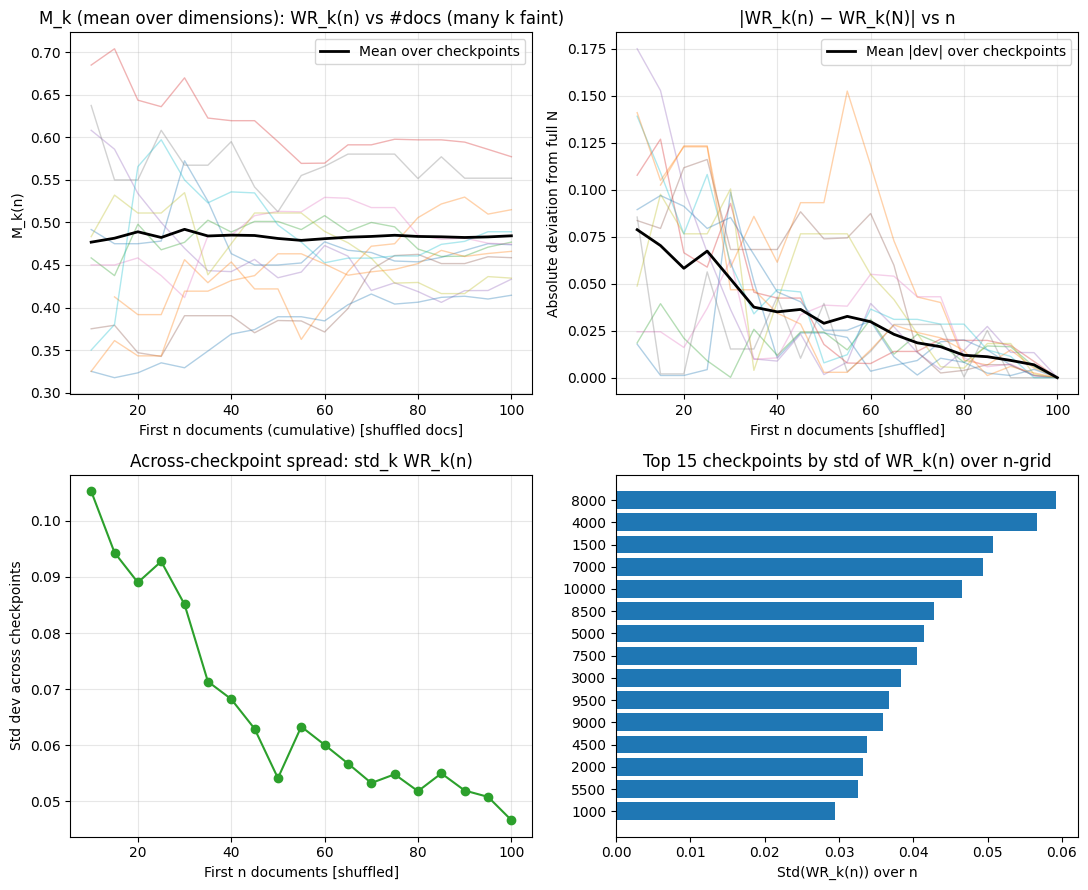

Documents: 100 total; grid [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Across-checkpoint std (last n = full): 0.04667911637727396


In [2]:
# Run cell 1 first (load_geval_stacked, focal_pairwise_outcome, checkpoint_step, DIMENSIONS, judge_fragment_from_id)

try:
    REPO
except NameError:
    REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pairwise_eval").is_dir()), Path.cwd())

# --- edit: export leaf + how you grow the doc window ---
PREFIX_EXPORT = REPO / ".deepeval" / "geval_exports" / "llama-2-13b" / "json"
PREFIX_LOAD_ALL_JUDGES = True
PREFIX_JUDGE_FRAGMENT = "mistral-medium-latest"  # ignored if PREFIX_LOAD_ALL_JUDGES

START_N = 10
STEP_N = 5

# How one scalar per checkpoint ``k`` is formed at each ``n``:
# - ``mean_over_dimensions``: M_k style — average of (judge-pooled) win rates within each dimension.
# - ``pooled``: ``win_rate_llm_pooled`` style — one win rate over every row in ``dims`` where ``k``
#   is left or right (pool judges + dimensions in one ratio). Matches the export table when
#   ``df_p`` uses the same judges and dimensions as that export.
WIN_RATE_AGGREGATION = "mean_over_dimensions"  # or "pooled"

# If True, permute unique doc_id order before cumulative n (all pairwise rows per doc stay together).
RANDOMIZE_DOC_ORDER = True
DOC_ORDER_SEED = 42  # only used when RANDOMIZE_DOC_ORDER is True

assert PREFIX_EXPORT.is_dir(), f"Missing export json dir: {PREFIX_EXPORT}"

df_p = load_geval_stacked(PREFIX_EXPORT, None if PREFIX_LOAD_ALL_JUDGES else PREFIX_JUDGE_FRAGMENT)
df_p = df_p.dropna(subset=["doc_id", "left", "right"])

# Unique docs in first-seen order in the stacked frame; optionally shuffle whole-document units only.
doc_order = df_p["doc_id"].drop_duplicates().tolist()
if RANDOMIZE_DOC_ORDER:
    _ord_rng = np.random.default_rng(DOC_ORDER_SEED)
    doc_order = list(doc_order)
    _ord_rng.shuffle(doc_order)
n_max = len(doc_order)

n_grid = list(range(START_N, n_max + 1, STEP_N))
if n_grid[-1] != n_max:
    n_grid.append(n_max)

_all = pd.unique(pd.concat([df_p["left"], df_p["right"]]))
CHECKPOINTS = sorted(
    (m for m in _all if str(m).startswith("checkpoint-") and checkpoint_step(str(m)) is not None),
    key=lambda m: checkpoint_step(str(m)),
)

dims = tuple(DIMENSIONS) if "DIMENSIONS" in globals() else (
    "faithfulness",
    "correctness",
    "completeness",
    "newsworthiness",
    "hygiene",
)

if WIN_RATE_AGGREGATION not in ("mean_over_dimensions", "pooled"):
    raise ValueError('WIN_RATE_AGGREGATION must be "mean_over_dimensions" or "pooled"')

print(
    "Document order for cumulative n:",
    f"shuffled by doc_id (seed={DOC_ORDER_SEED})" if RANDOMIZE_DOC_ORDER else "first-seen in stacked frame",
)

_xlabel_n = "First n documents (cumulative)" + (" [shuffled docs]" if RANDOMIZE_DOC_ORDER else "")
_xlabel_n_short = "First n documents" + (" [shuffled]" if RANDOMIZE_DOC_ORDER else "")

rows = []
for n in n_grid:
    keep = set(doc_order[:n])
    sub = df_p[df_p["doc_id"].isin(keep)]
    by_ck = {}
    for k in CHECKPOINTS:
        if WIN_RATE_AGGREGATION == "pooled":
            blk = sub[(sub["dimension"].isin(dims)) & ((sub["left"] == k) | (sub["right"] == k))]
            s = blk.apply(lambda r: focal_pairwise_outcome(r, k), axis=1).dropna()
            by_ck[k] = float(s.mean()) if len(s) else float("nan")
        else:
            dim_wr = []
            for d in dims:
                blk = sub[(sub["dimension"] == d) & ((sub["left"] == k) | (sub["right"] == k))]
                s = blk.apply(lambda r: focal_pairwise_outcome(r, k), axis=1).dropna()
                dim_wr.append(float(s.mean()) if len(s) else float("nan"))
            by_ck[k] = float(np.nanmean(dim_wr))
    spread = float(np.nanstd(list(by_ck.values()), ddof=1))
    rows.append({"n": n, "spread_across_ck": spread, **{f"wr__{k}": by_ck[k] for k in CHECKPOINTS}})

curve = pd.DataFrame(rows).sort_values("n")
N_full = int(curve["n"].max())
full_row = curve.loc[curve["n"] == N_full].iloc[0]

_curve_mode = (
    "M_k (mean over dimensions)"
    if WIN_RATE_AGGREGATION == "mean_over_dimensions"
    else "Pooled WR (win_rate_llm_pooled style)"
)
print("WIN_RATE_AGGREGATION:", WIN_RATE_AGGREGATION, "→", _curve_mode)

# Distance to full-data mean per checkpoint
dev = curve.copy()
for k in CHECKPOINTS:
    col = f"wr__{k}"
    dev[f"dev__{k}"] = (dev[col] - float(full_row[col])).abs()

# --- Figure 1: a few checkpoints + mean over all checkpoints of M_k(n) ---
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
ax0, ax1, ax2, ax3 = axes.ravel()

steps = [checkpoint_step(k) for k in CHECKPOINTS]
order = np.argsort(steps)
# plot a thin sample of checkpoints to avoid clutter
idxs = np.linspace(0, len(CHECKPOINTS) - 1, num=min(12, len(CHECKPOINTS)), dtype=int)
for i in idxs:
    k = CHECKPOINTS[int(i)]
    ax0.plot(curve["n"], curve[f"wr__{k}"], alpha=0.35, lw=1)
mean_curve = curve[[f"wr__{k}" for k in CHECKPOINTS]].mean(axis=1)
ax0.plot(curve["n"], mean_curve, "k-", lw=2, label="Mean over checkpoints")
ax0.set_title(f"{_curve_mode}: WR_k(n) vs #docs (many k faint)")
ax0.set_xlabel(_xlabel_n)
ax0.set_ylabel("WR_k(n)" if WIN_RATE_AGGREGATION == "pooled" else "M_k(n)")
ax0.grid(True, alpha=0.3)
ax0.legend()

# same subset for deviation plot
for i in idxs:
    k = CHECKPOINTS[int(i)]
    ax1.plot(dev["n"], dev[f"dev__{k}"], alpha=0.35, lw=1)
ax1.plot(dev["n"], dev[[f"dev__{k}" for k in CHECKPOINTS]].mean(axis=1), "k-", lw=2, label="Mean |dev| over checkpoints")
ax1.set_title("|WR_k(n) − WR_k(N)| vs n")
ax1.set_xlabel(_xlabel_n_short)
ax1.set_ylabel("Absolute deviation from full N")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(curve["n"], curve["spread_across_ck"], "o-", color="C2")
ax2.set_title("Across-checkpoint spread: std_k WR_k(n)")
ax2.set_xlabel(_xlabel_n_short)
ax2.set_ylabel("Std dev across checkpoints")
ax2.grid(True, alpha=0.3)

# Per-checkpoint: std of M_k(n) over the n_grid (how much that checkpoint moved along the curve)
per_ck_variation = []
for k in CHECKPOINTS:
    y = curve[f"wr__{k}"].astype(float).values
    per_ck_variation.append((k, float(np.nanstd(y, ddof=1)), float(np.nanmax(y) - np.nanmin(y))))
pv = pd.DataFrame(per_ck_variation, columns=["checkpoint", "std_over_n", "range_over_n"]).sort_values(
    "std_over_n", ascending=False
)
ax3.barh(range(len(pv.head(15))), pv.head(15)["std_over_n"].values, tick_label=[checkpoint_step(x) for x in pv.head(15)["checkpoint"]])
ax3.set_title("Top 15 checkpoints by std of WR_k(n) over n-grid")
ax3.set_xlabel("Std(WR_k(n)) over n")
ax3.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Documents: {n_max} total; grid {n_grid}")
print("Across-checkpoint std (last n = full):", float(curve["spread_across_ck"].iloc[-1]))
#pv.head(10)


### Deviation **across** sample sizes $n$ (fixed checkpoint)


(Using WIN_RATE_AGGREGATION = 'mean_over_dimensions' from the prefix cell)
Focal checkpoint: checkpoint-4500-inputs-refs-preds-1000-examples
  step = 4500
  n_grid points: 19
  mean over n of M_k(n): 0.5520
  std over n (ddof=1):   0.0338
  range over n:          0.1625
  M_k(N) full:           0.5670
  max |M_k(n)-M_k(N)| for n<N: 0.1170
  RMSE vs M_k(N) over n<N:     0.0372


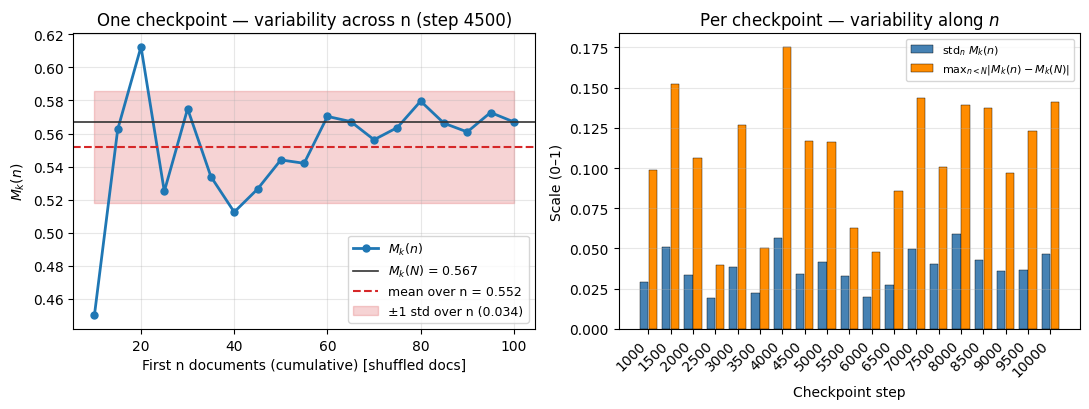

In [3]:
# Run cumulative-prefix cell first (defines curve, CHECKPOINTS, n_grid, checkpoint_step).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_xdoc_lbl = "First n documents (cumulative)" + (
    " [shuffled docs]" if globals().get("RANDOMIZE_DOC_ORDER") else ""
)

# Pick one checkpoint by full model id, or None = use middle of training curve by step
FOCAL_CK: str | None = "checkpoint-4500-inputs-refs-preds-1000-examples"  # e.g. "checkpoint-5000-inputs-refs-preds-1000-examples"
if FOCAL_CK is None:
    steps = [checkpoint_step(k) for k in CHECKPOINTS]
    mid = int(np.argsort(steps)[len(steps) // 2])
    FOCAL_CK = CHECKPOINTS[mid]

col = f"wr__{FOCAL_CK}"
if col not in curve.columns:
    raise KeyError(f"{FOCAL_CK!r} not in curve columns")

y = curve[col].astype(float).values
ns = curve["n"].astype(int).values
if "WIN_RATE_AGGREGATION" in globals():
    print(f"(Using WIN_RATE_AGGREGATION = {WIN_RATE_AGGREGATION!r} from the prefix cell)")

mean_over_n = float(np.nanmean(y))
std_over_n = float(np.nanstd(y, ddof=1))
rng_over_n = float(np.nanmax(y) - np.nanmin(y))
y_full = float(y[-1])
mask_pre = ns < ns[-1]
res = y[mask_pre] - y_full
max_abs_vs_full = float(np.nanmax(np.abs(res))) if res.size else 0.0
rmse_vs_full = float(np.sqrt(np.nanmean(res**2))) if res.size else 0.0

print(f"Focal checkpoint: {FOCAL_CK}")
print(f"  step = {checkpoint_step(FOCAL_CK)}")
print(f"  n_grid points: {len(ns)}")
print(f"  mean over n of M_k(n): {mean_over_n:.4f}")
print(f"  std over n (ddof=1):   {std_over_n:.4f}")
print(f"  range over n:          {rng_over_n:.4f}")
print(f"  M_k(N) full:           {y_full:.4f}")
print(f"  max |M_k(n)-M_k(N)| for n<N: {max_abs_vs_full:.4f}")
print(f"  RMSE vs M_k(N) over n<N:     {rmse_vs_full:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(ns, y, "o-", lw=2, ms=5, label=r"$M_k(n)$")
ax.axhline(y_full, color="0.2", ls="-", lw=1.2, label=f"$M_k(N)$ = {y_full:.3f}")
ax.axhline(mean_over_n, color="C3", ls="--", lw=1.5, label=f"mean over n = {mean_over_n:.3f}")
ax.fill_between(ns, mean_over_n - std_over_n, mean_over_n + std_over_n, alpha=0.2, color="C3", label=f"±1 std over n ({std_over_n:.3f})")
ax.set_xlabel(_xdoc_lbl)
ax.set_ylabel(r"$M_k(n)$")
ax.set_title(f"One checkpoint — variability across n (step {checkpoint_step(FOCAL_CK)})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)

# All checkpoints: spread of M_k(n) along n + distance from full-data M_k(N)
per = []
for k in CHECKPOINTS:
    yy = curve[f"wr__{k}"].astype(float).values
    nn = curve["n"].astype(int).values
    yN = float(yy[-1])
    m = nn < nn[-1]
    res_k = yy[m] - yN
    per.append(
        {
            "step": checkpoint_step(k),
            "checkpoint": k,
            "std_n": float(np.nanstd(yy, ddof=1)),
            "range_n": float(np.nanmax(yy) - np.nanmin(yy)),
            "max_abs_vs_N": float(np.nanmax(np.abs(res_k))) if res_k.size else 0.0,
            "rmse_vs_N": float(np.sqrt(np.nanmean(res_k**2))) if res_k.size else 0.0,
        }
    )
pv2 = pd.DataFrame(per).sort_values("step")

axb = axes[1]
xpos = np.arange(len(pv2))
axb.bar(xpos - 0.2, pv2["std_n"], width=0.38, color="steelblue", edgecolor="k", linewidth=0.3, label=r"std$_n$ $M_k(n)$")
axb.bar(xpos + 0.2, pv2["max_abs_vs_N"], width=0.38, color="darkorange", edgecolor="k", linewidth=0.3, label=r"max$_{n<N}$|$M_k(n)-M_k(N)|$")
axb.set_xticks(xpos)
axb.set_xticklabels(pv2["step"].astype(str), rotation=45, ha="right")
axb.set_xlabel("Checkpoint step")
axb.set_ylabel("Scale (0–1)")
axb.set_title("Per checkpoint — variability along $n$")
axb.legend(loc="upper right", fontsize=8)
axb.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#pv2.sort_values("std_n", ascending=False).head(12)


In [64]:
path = "Data/eval/25"

#get all folders in the path
folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]

print(folders)

['nb-gpt-j-6b', 'viking-13b', 'gemma-2b', 'normistral-11b-apptainer', 'llama-3.1-8b', 'norwai-mistral-7b', 'gemma-2-9b', 'llama-2-13b', 'normistral-11b-long-apptainer', 'norskgpt-llama3-8b', 'gemma-2b----27 docs,5 pairs']


In [65]:
for folder in folders:
    print(folder)
    #get all files in the folder
    files = [f for f in os.listdir(os.path.join(path, folder)) if os.path.isfile(os.path.join(path, folder, f))]
    chs = [f for f in files if f.startswith("checkpoint-")]
    print(len(chs))
    
    

nb-gpt-j-6b
12
viking-13b
19
gemma-2b
19
normistral-11b-apptainer
19
llama-3.1-8b
9
norwai-mistral-7b
19
gemma-2-9b
19
llama-2-13b
19
normistral-11b-long-apptainer
4
norskgpt-llama3-8b
17
gemma-2b----27 docs,5 pairs
19


In [36]:
path = ".deepeval/geval_exports/llama-2-13b/json"
import json
import os
import pandas as pd
#get all files in the path
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

judges = ["anthropic__claude-3-5-haiku-20241022",
"google__gemini-2.5-flash-preview-05-20",
"mistral-medium-latest",
"gpt-3.5-turbo"
]


In [55]:
for i in range(len(files)):
    if judges[3] in files[i]:
        df = pd.read_json(os.path.join(path, files[i]))
        print(files[i])
        # Fix boolean index: use parentheses around each condition before &
        filtered_df = df[(df['doc_id'] == "doc_41") & (df['left'] == "checkpoint-4500-inputs-refs-preds-1000-examples")]["choice_side"]
        print(filtered_df)

geval__gpt-3.5-turbo__newsworthiness.json
163    tie
Name: choice_side, dtype: object
geval__gpt-3.5-turbo__hygiene.json
163    tie
Name: choice_side, dtype: object
geval__gpt-3.5-turbo__correctness.json
163    tie
Name: choice_side, dtype: object
geval__gpt-3.5-turbo__faithfulness.json
163    tie
Name: choice_side, dtype: object
geval__gpt-3.5-turbo__completeness.json
163    tie
Name: choice_side, dtype: object


In [3]:
import pandas as pd

data = pd.read_csv("evaluation_suite/outputs/human_eval_pairs_llama-2-13b/human_eval_answer_key.csv")
data[data["selection_bucket"]=="low_agreement"].head(10)


,item_id,doc_id,left_model,right_model,votes_left,votes_right,votes_tie,votes_completeness_left,votes_completeness_right,votes_completeness_tie,...,votes_faithfulness_tie,votes_hygiene_left,votes_hygiene_right,votes_hygiene_tie,votes_newsworthiness_left,votes_newsworthiness_right,votes_newsworthiness_tie,majority_label_raw,expected_label_on_blinded_sides,selection_bucket
0,human_eval_0001,doc_18,checkpoint-10000-inputs-refs-preds-1000-examples,checkpoint-8500-inputs-refs-preds-1000-examples,10,5,5,2,0,2,...,0,2,2,0,2,0,2,left,A,low_agreement
1,human_eval_0002,doc_36,checkpoint-10000-inputs-refs-preds-1000-examples,checkpoint-5500-inputs-refs-preds-1000-examples,6,6,8,1,1,2,...,2,2,1,1,1,2,1,tie,Tie,low_agreement
2,human_eval_0003,doc_16,checkpoint-9000-inputs-refs-preds-1000-examples,checkpoint-3500-inputs-refs-preds-1000-examples,4,8,8,1,2,1,...,2,2,1,1,1,1,2,tie,Tie,low_agreement
3,human_eval_0004,doc_79,checkpoint-2500-inputs-refs-preds-1000-examples,checkpoint-9500-inputs-refs-preds-1000-examples,8,4,8,2,1,1,...,2,2,1,1,1,1,2,tie,Tie,low_agreement
4,human_eval_0005,doc_57,checkpoint-2500-inputs-refs-preds-1000-examples,checkpoint-2000-inputs-refs-preds-1000-examples,10,8,2,2,1,1,...,0,2,2,0,2,2,0,left,B,low_agreement
5,human_eval_0006,doc_1,checkpoint-2500-inputs-refs-preds-1000-examples,checkpoint-9500-inputs-refs-preds-1000-examples,6,7,7,2,1,1,...,2,1,2,1,0,2,2,tie,Tie,low_agreement
6,human_eval_0007,doc_31,checkpoint-1000-inputs-refs-preds-1000-examples,checkpoint-3000-inputs-refs-preds-1000-examples,4,9,7,1,1,2,...,1,1,2,1,0,2,2,right,B,low_agreement
7,human_eval_0008,doc_48,checkpoint-9500-inputs-refs-preds-1000-examples,checkpoint-3500-inputs-refs-preds-1000-examples,10,9,1,2,2,0,...,0,2,1,1,2,2,0,left,B,low_agreement
8,human_eval_0009,doc_62,checkpoint-1500-inputs-refs-preds-1000-examples,checkpoint-7500-inputs-refs-preds-1000-examples,3,9,8,0,2,2,...,1,0,2,2,1,1,2,right,B,low_agreement
9,human_eval_0010,doc_82,checkpoint-9000-inputs-refs-preds-1000-examples,checkpoint-6000-inputs-refs-preds-1000-examples,3,8,9,1,1,2,...,2,0,3,1,0,2,2,tie,Tie,low_agreement


In [60]:
data["selection_bucket"].value_counts()

selection_bucket
low_agreement             30
top_checkpoint_matchup    30
high_agreement            20
gpt4o_challenged          20
Name: count, dtype: int64

In [ ]:
data.shape



(100, 25)

In [ ]:
import json
#data = json.load(open("human evaluation/_tmp_check/human_eval_dataset.jsonl"))
# The error occurs because json.load expects the file to be in JSON format, but 'human_eval_dataset.jsonl' is a JSON Lines file (each line is a separate JSON object).
# To properly load all data, read each line and parse individually, e.g. as a list of dicts:
with open("evaluation_suite/outputs/human_eval_pairs_llama-2-13b/human_eval_dataset.jsonl", "r") as f:
    data = [json.loads(line) for line in f]




In [63]:
i = 0
for item in data:
    if item["summary_a"] == item["summary_b"]:
        print(data[0]['llm_decisions']['completeness'] == data[0]['llm_decisions']['faithfulness']== data[0]['llm_decisions']['correctness']== data[0]['llm_decisions']['newsworthiness']== data[0]['llm_decisions']['hygiene'])
        i += 1
        #break
print(i)


0


In [64]:
data[0]

{'item_id': 'human_eval_0001',
 'doc_id': 'doc_18',
 'source_text': '\n| |Dato: 8. januar 2003 |\n| | |\n| | |\n| |BEBS |\n| |/02 |\n| |\n| |\n|Bergenhus bydelsstyre |\n| |\n| |\n| |\n|Protokoll for sak vedtatt på fullmakt 20.12.02 |\n| |\n| |MACH |BEBD-0220-200001418-90|\n| |\n\nHva saken gjelder:\n\nProtokoll for sak vedtatt på fullmakt 20.12.2002.\n\nForslag til vedtak:\n\nProtokollen tatt til etterretning.\n\nOle Vorland\nbydelsdirektør\n\n',
 'reference_summary': 'Dokumentet er en protokoll fra Bergenhus bydelsstyre som omhandler en sak vedtatt på fullmakt den 20. desember 2002. Forslaget til vedtak er at protokollen tas til etterretning.',
 'summary_a': 'Dokumentet inneholder protokollen fra Bergenhus bydelsstyres møte den 20. desember 2002, hvor det ble vedtatt en sak på fullmakt. Protokollen skal tas til etterretning. Bydelsdirektør Ole Vorland har signert dokumentet som bekreftelse av vedtaket. Saken omhandler en spesifikk sak som ble behandlet i møtet og er en del av bydelsst